# Bigger May Be Better: Leveraging Sentence Transformer Embedding Models for Review Classification
## Portia Cooper

**Assigment Goals:**
- a) determine whether or not a piece of text is a movie/TV show review and
- b) whether or not each review is positive (the movie/TV show is recommended) or negative (the movie/TV show should be avoided).

**My Approach:**
I am using the standard sklearn logistic regression model in conjuction with a sentence transformer embedding model, selected to maxmize F1 score. Additionally, I perform data preprocessing to remove any html noise and apply a final prediction correction technique by converting labels for non-english text to 0 (not a review) based on my observations of the training data.

**A few notes:**
- This notebook should be compatible with both the provided Docker container and Google Colab (suggested, as GPU-access will lower the runtime significantly). **To run on colab, make sure all of the specified cells are NOT commented out.** And be preprared to update the data and save paths.
- On an A100 GPU, expect the final model training and evaluation to take 177.88 and 35.50 seconds, respectivly.
- The final model predictions will be saved to the data folder under the filename submission.csv, by default.

In [1]:
# Optional cell (only use if running on Google Collab)
# from google.colab import drive
# drive.mount('/content/drive')
# %cd /content/drive/MyDrive/temp_final_project/grad-level-term-project-kaggle-competition-pcoopercoder-main

Mounted at /content/drive
/content/drive/MyDrive/temp_final_project/grad-level-term-project-kaggle-competition-pcoopercoder-main


In [2]:
# Import all necessary libraries
import re
import pickle
import html
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score
from sklearn.model_selection import train_test_split
from sentence_transformers import SentenceTransformer
from typing import Iterator, Iterable, List, Tuple, Text, Union

## Step 1: Clean Up the Input Data

This includes:
- Removing any html artifacts (such as the page break tag)
- Making all of the text lowercase
- Removing lines with no TEXT column entries from the data

In [3]:
def preprocess(text: List):
    cleaned_text = []
    # remove all html tags and artifacts
    for t in text:
      t = html.unescape(t)
      t = t.lower()
      t = re.sub(r'<.*?>', '', t)
      cleaned_text.append(t)
    return cleaned_text

def fetch_data(path: Text):
    df = pd.read_csv(path)
    df = df.dropna(subset=["TEXT"])
    df["TEXT"] = preprocess(df["TEXT"])
    return df
    # return preprocess(df["TEXT"])

## Step 2: Define the Review Classifer Class

The goal here was to create a framework which facilated easy comparison of the performances of different sizes of embedding models.

Note: The labels for the three classes are defined as...
- 0 = Not a (movie/TV show) review
- 1 = Positive (movie/TV show) review
- 2 = Negative (movie/TV show) review

In [4]:
class Review_Classifier:
  def __init__(self, emb_model_name):
    self.emb_model_name = emb_model_name
    self.embedding_model = SentenceTransformer(emb_model_name)
    self.label_enc = LabelEncoder()
    self.log_reg_classifier = None
    self.val_f1_score = None


  def train_model(self, text: List, labels: List):
    X = self.embedding_model.encode(text, show_progress_bar=True, batch_size=64)
    y = self.label_enc.fit_transform(labels)

    self.log_reg_classifier = LogisticRegression(max_iter=100000)
    self.log_reg_classifier.fit(X, y)


  def is_not_english(self, text, threshold=0.7):
    # count characters outside the standard ASCII range
    non_english_count = sum(1 for char in text if ord(char) > 127)
    # calc ratio of non-english characters
    if len(text) == 0:
        return 1
    ratio = non_english_count / len(text)
    return ratio > threshold


  def adjust_non_english_preds(self, X:list, y: List):
    for i in range(len(X)):
      if self.is_not_english(X[i]):
        y[i] = 0
    return y


  def plot_confusion_matrix(self, y: np.ndarray, y_pred: np.ndarray):
    cm = confusion_matrix(y, y_pred)
    plt.figure(figsize=(5, 5))
    sns.heatmap(cm, fmt="d", cbar=False, cmap="Blues", xticklabels=["Not a Review", "Negative", "Positive"], yticklabels=["Not a Review", "Negative", "Positive"], annot=True)
    plt.xlabel("Pred")
    plt.ylabel("True")
    plt.show()


  def val_model(self, text: List, labels: List):
    X = self.embedding_model.encode(text, show_progress_bar=True, batch_size=64)
    y = self.label_enc.fit_transform(labels)

    y_pred = self.log_reg_classifier.predict(X)
    y_pred = self.adjust_non_english_preds(text, y_pred)

    print(self.emb_model_name)
    self.plot_confusion_matrix(y, y_pred)
    print(classification_report(y, y_pred))
    self.val_f1_score = f1_score(y, y_pred, average='weighted')


  def test_model(self, model, ids: List, text: List, save_path: Text):
    X = self.embedding_model.encode(text, show_progress_bar=True, batch_size=64)

    y_pred = self.log_reg_classifier.predict(X)
    y_pred = self.adjust_non_english_preds(text, y_pred)

    # save data in the required format for submission
    df = pd.DataFrame({"ID": ids, "LABEL": y_pred})
    df.to_csv(save_path, index=False)

## Step 3: Evaluate the Embedding Models on a Held-out Subset (20%) of the Train Data

I use both a confusion matrix and classifcation report to check overall performance but select final embedding model based on F1 score.

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/879 [00:00<?, ?it/s]

Batches:   0%|          | 0/220 [00:00<?, ?it/s]

sentence-transformers/all-MiniLM-L6-v2


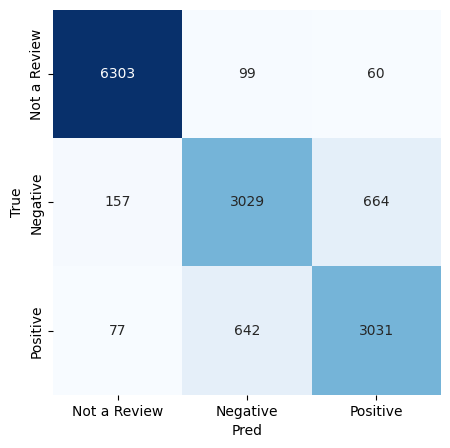

              precision    recall  f1-score   support

           0       0.96      0.98      0.97      6462
           1       0.80      0.79      0.80      3850
           2       0.81      0.81      0.81      3750

    accuracy                           0.88     14062
   macro avg       0.86      0.86      0.86     14062
weighted avg       0.88      0.88      0.88     14062



modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/879 [00:00<?, ?it/s]

Batches:   0%|          | 0/220 [00:00<?, ?it/s]

sentence-transformers/all-mpnet-base-v2


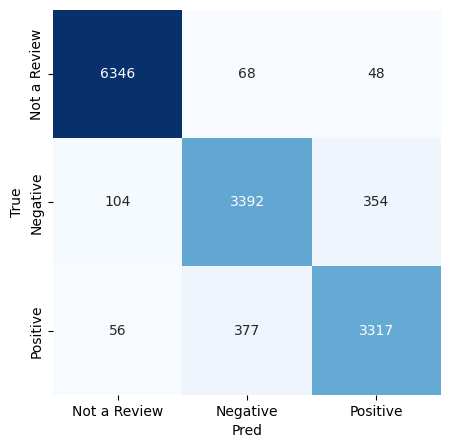

              precision    recall  f1-score   support

           0       0.98      0.98      0.98      6462
           1       0.88      0.88      0.88      3850
           2       0.89      0.88      0.89      3750

    accuracy                           0.93     14062
   macro avg       0.92      0.92      0.92     14062
weighted avg       0.93      0.93      0.93     14062



modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/266 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/695 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/297 [00:00<?, ?B/s]

Batches:   0%|          | 0/879 [00:00<?, ?it/s]

Batches:   0%|          | 0/220 [00:00<?, ?it/s]

mixedbread-ai/mxbai-embed-large-v1


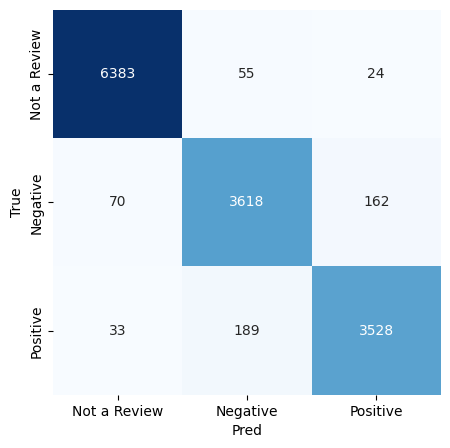

              precision    recall  f1-score   support

           0       0.98      0.99      0.99      6462
           1       0.94      0.94      0.94      3850
           2       0.95      0.94      0.95      3750

    accuracy                           0.96     14062
   macro avg       0.96      0.96      0.96     14062
weighted avg       0.96      0.96      0.96     14062



In [5]:
embedding_model_names = ["sentence-transformers/all-MiniLM-L6-v2","sentence-transformers/all-mpnet-base-v2", "mixedbread-ai/mxbai-embed-large-v1"]

best_emb_model = None
best_f1_score = 0

train, val = train_test_split(fetch_data(path="./data/train.csv"), test_size=0.2, random_state=1)

for embedding_model in embedding_model_names:
  model = Review_Classifier(embedding_model)
  model.train_model(train["TEXT"].to_list(), train["LABEL"].to_list())

  model.val_model(val["TEXT"].to_list(), val["LABEL"].to_list())

  if model.val_f1_score > best_f1_score:
    best_emb_model = embedding_model
    best_f1_score = model.val_f1_score

## Step 4: Generate Test Data Predictions Using the Embedding Model which Yielded the Hightest Val F1 Score

In [6]:
print(f"Using model: {best_emb_model}")
model = Review_Classifier(best_emb_model)
train = fetch_data(path="./data/train.csv") # train on the full set now
test = fetch_data(path="./data/test.csv")

train_start = time.time()
model.train_model(train["TEXT"].to_list(), train["LABEL"].to_list())
train_end = time.time()
train_time = train_end - train_start
print(f"Train time: {train_time:.2f} seconds")

test_start = time.time()
model.test_model(model, test["ID"].to_list(), test["TEXT"].to_list(), save_path="./data/submission.csv")
test_end = time.time()
test_time = test_end - test_start
print(f"Test time: {test_time:.2f} seconds")

Using model: mixedbread-ai/mxbai-embed-large-v1


Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

Batches:   0%|          | 0/1099 [00:00<?, ?it/s]

Train time: 180.71 seconds


Batches:   0%|          | 0/275 [00:00<?, ?it/s]

Test time: 36.35 seconds


## Step 5 (Optional): Save Model Pickle File for Later Use

In [7]:
# save model for reuse
with open('./model.pkl', 'wb') as file:
    pickle.dump(model.log_reg_classifier, file)

In [8]:
# Only run this if using colab (will save you from unecessary idling and more usage costs)
# from google.colab import runtime
# runtime.unassign()